# 04 Scenario
## 시나리오


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def load_table(name):
    return pd.read_csv(TABLE_DIR / name)

def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

def pct(x, digits=2):
    return (x.astype(float) * 100).round(digits)


## Top-K Policy
### Top-K 정책


,policy,review_count,tp,fp,weighted_fp,precision_pct,weighted_precision_pct,capture_rate_pct,lift,missed_default
0,Top 1%,4590,4589,1,20,99.98,99.57,3.86,3.861152,114239
1,Top 5%,22946,22742,204,4080,99.11,84.79,19.14,3.827659,96086
2,Top 10%,45892,44326,1566,31320,96.59,58.60,37.30,3.730209,74502
3,Top 15%,68837,63994,4843,96860,92.96,39.78,53.85,3.590285,54834
4,Top 20%,91783,81176,10607,212140,88.44,27.68,68.31,3.415678,37652


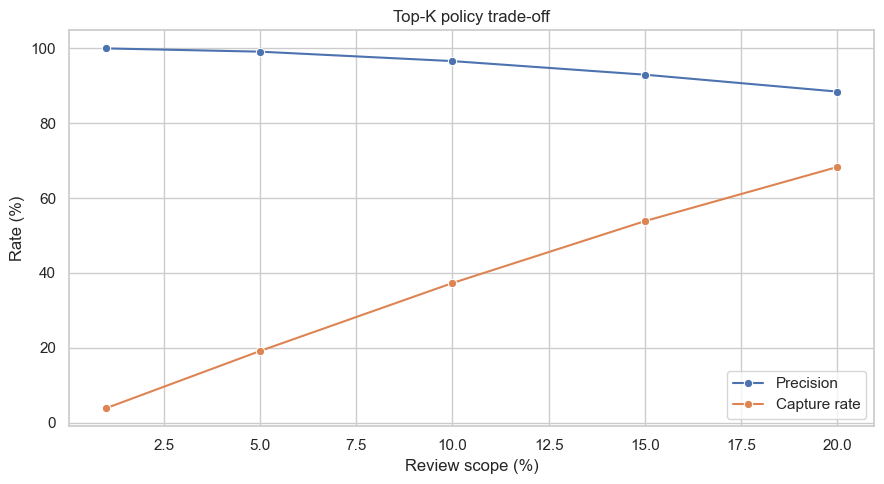

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\amex-credit-risk-decisioning\outputs\figures\topk_policy_tradeoff_precision_capture.png


In [2]:
topk = load_table("topk_policy_tradeoff.csv")
weighted = load_table("weighted_policy_tradeoff.csv")
policy = topk.merge(weighted[["policy", "weighted_fp", "weighted_precision", "weighted_lift"]], on="policy", how="left")
for col in ["precision", "weighted_precision", "capture_rate"]:
    policy[f"{col}_pct"] = pct(policy[col])
policy["review_scope_pct"] = policy["review_rate"] * 100
display(
    policy[
        [
            "policy",
            "review_count",
            "tp",
            "fp",
            "weighted_fp",
            "precision_pct",
            "weighted_precision_pct",
            "capture_rate_pct",
            "lift",
            "missed_default",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=policy, x="review_scope_pct", y="precision_pct", marker="o", ax=ax, label="Precision")
sns.lineplot(data=policy, x="review_scope_pct", y="capture_rate_pct", marker="o", ax=ax, label="Capture rate")
ax.set_title("Top-K policy trade-off")
ax.set_xlabel("Review scope (%)")
ax.set_ylabel("Rate (%)")
ax.legend()
path = save_figure("topk_policy_tradeoff_precision_capture.png")
plt.show()
print(path)


Top-K 확대는 더 많은 default를 잡지만 review workload를 늘린다.


## Cost Scenario
### 비용 시나리오


,scenario,policy,review_rate,tp,fp,effective_review_count,avoided_loss,operating_cost_total,net_benefit
83,Aggressive,Top 28%,0.28,101611,26885,639311.0,21338.31,4271.955,17066.355
49,Base,Top 17%,0.17,71205,6811,207425.0,7120.50,2755.350,4365.150
9,Conservative,Top 4%,0.04,18245,112,20485.0,547.35,432.100,115.250


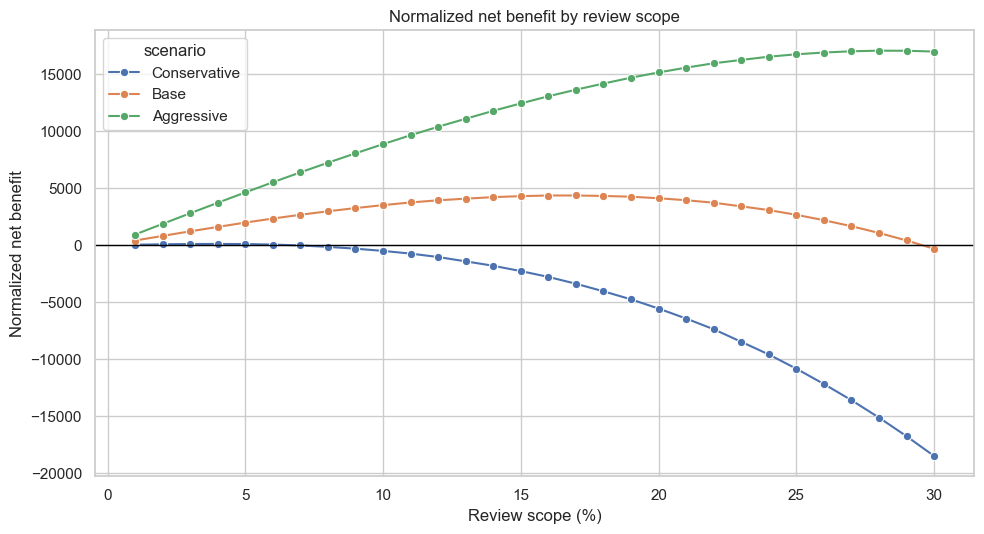

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\amex-credit-risk-decisioning\outputs\figures\normalized_net_benefit_by_review_scope.png


In [3]:
scenario = load_table("normalized_net_benefit_by_review_scope.csv")
best = (
    scenario.sort_values("net_benefit", ascending=False)
    .groupby("scenario", as_index=False)
    .head(1)
    .sort_values("scenario")
)
display(
    best[
        [
            "scenario",
            "policy",
            "review_rate",
            "tp",
            "fp",
            "effective_review_count",
            "avoided_loss",
            "operating_cost_total",
            "net_benefit",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=scenario, x="review_scope_pct", y="net_benefit", hue="scenario", marker="o", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Normalized net benefit by review scope")
ax.set_xlabel("Review scope (%)")
ax.set_ylabel("Normalized net benefit")
path = save_figure("normalized_net_benefit_by_review_scope.png")
plt.show()
print(path)


Base scenario 최고점은 Top 17%다.


## Decision
### 정책 판단


In [4]:
base = scenario[scenario["scenario"].eq("Base")].sort_values("net_benefit", ascending=False).reset_index(drop=True)
selected = base.iloc[0]
decision = pd.DataFrame(
    [
        ["score_use", "manual_review_priority"],
        ["base_threshold", selected["policy"]],
        ["base_net_benefit", round(selected["net_benefit"], 2)],
        ["nondefault_correction", "20x"],
        ["deployment_boundary", "not_automatic_adverse_action"],
    ],
    columns=["item", "decision"],
)
display(decision)


,item,decision
0,score_use,manual_review_priority
1,base_threshold,Top 17%
2,base_net_benefit,4365.15
3,nondefault_correction,20x
4,deployment_boundary,not_automatic_adverse_action


최종 산출물은 review queue 우선순위와 monitoring 정책이다.
